# Minesweeper with Deep Reinforcement Learning

In this notebook you will compare three deep reinforcement-learning methods on Minesweeper:
- DQN
- REINFORCE
- actor-critic

Most of the infrastructure has been moved to `deep_rl_notebook_support.py` so that the notebook stays focused on the decisions you are meant to experiment with.


## What you are given

The support module already provides:
- the Minesweeper environment
- baseline neural-network implementations, including a convolutional DQN baseline
- baseline DQN, REINFORCE, and actor-critic agents
- training, evaluation, and visualization helpers

The current state representation is a flattened one-hot encoding of the visible board, with 10 channels per cell.

For DQN, the selected action is now encoded as one extra spatial channel before the CNN predicts a scalar value `Q(s, a)`.

You do not need to edit the support module to start experimenting. The main cell to change is the starter experiment below. If you want to inspect the full implementation, open `deep_rl_notebook_support.py`.


In [5]:
import importlib
import deep_rl_notebook_support

importlib.reload(deep_rl_notebook_support)

from deep_rl_notebook_support import (
    ActorCriticAgent,
    ConstantSchedule,
    DEFAULT_PLOT_WINDOW,
    DQNAgent,
    LinearSchedule,
    MinesweeperEnv,
    REINFORCEAgent,
    compare_agents,
    plot_schedule_traces,
    plot_training_rewards,
    plot_win_rates,
    show_results_table,
    show_rollout,
)


## Where to experiment

The most useful knobs to change are:
- `hidden_sizes`: the size of the dense layers in the baseline networks
- `epsilon_schedule`: how DQN shifts from exploration to exploitation
- `learning_rate_schedule`: how quickly each method updates its parameters
- `train_episodes`: how long you train before comparing the methods

A good workflow is to change one idea at a time and keep notes about what happened.


## Starter experiment

The cell below is the main place to work.

Suggestions:
- Start by changing only one method.
- Keep the other two baselines fixed so that comparisons stay meaningful.
- If training becomes unstable, try a smaller learning rate before making the network larger.
- If DQN gets stuck, try changing the epsilon schedule before changing everything else.



Training dqn ...
Episode   10 | avg reward -9.220 | win rate  0.0%
Episode   20 | avg reward -9.140 | win rate  0.0%
Episode   30 | avg reward -9.280 | win rate  0.0%
Episode   40 | avg reward 12.870 | win rate 20.0%
Episode   50 | avg reward  1.630 | win rate 10.0%
Episode   60 | avg reward -9.120 | win rate  0.0%
Episode   70 | avg reward  1.650 | win rate 10.0%
Episode   80 | avg reward -9.440 | win rate  0.0%
Episode   90 | avg reward  1.580 | win rate 10.0%
Episode  100 | avg reward  1.560 | win rate 10.0%
Episode  110 | avg reward  1.630 | win rate 10.0%
Episode  120 | avg reward  1.920 | win rate 10.0%
Episode  130 | avg reward -9.300 | win rate  0.0%
Episode  140 | avg reward -9.170 | win rate  0.0%
Episode  150 | avg reward -9.190 | win rate  0.0%
Episode  160 | avg reward 12.930 | win rate 20.0%
Episode  170 | avg reward -9.280 | win rate  0.0%
Episode  180 | avg reward -9.230 | win rate  0.0%
Episode  190 | avg reward  1.510 | win rate 10.0%
Episode  200 | avg reward -9.340

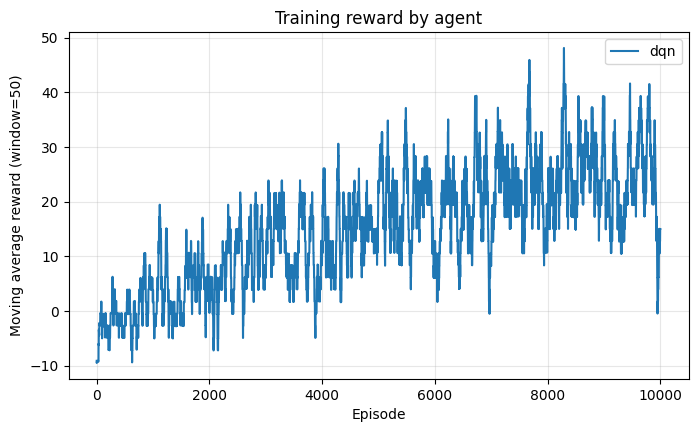

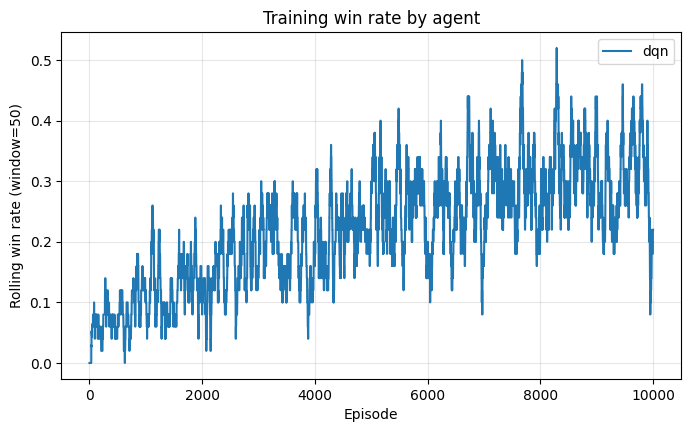

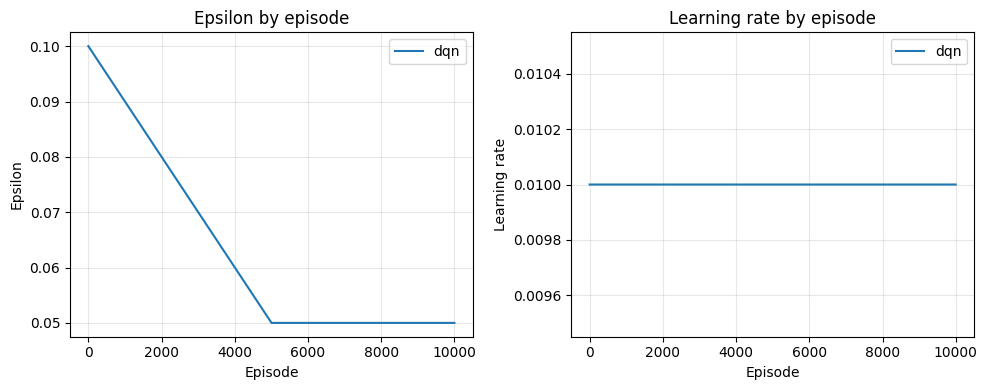

| agent | eval avg reward | eval win rate | eval avg steps |
|---|---:|---:|---:|
| dqn | 22.61 | 0.29 | 4.96 |

In [6]:
# Board and reward configuration.
# Try changing the board size only after you get a reasonable baseline working.
env_config = {
    'size': 4,
    'num_mines': 3,
    'safe_first_move': True,
    'reveal_reward': 0.1,
    'win_reward': 100.0,
    'lose_reward': -10.0,
    'invalid_reward': -0.25,
}

# Training settings.
# Lower report_every if you want more frequent progress updates while training.
train_episodes = 1000
eval_episodes = 100
report_every = 10
plot_window = DEFAULT_PLOT_WINDOW

state_size = env_config['size'] * env_config['size'] * MinesweeperEnv.CHANNELS_PER_CELL
action_size = env_config['size'] * env_config['size']

agent_builders = {
    'dqn': lambda: DQNAgent(
        state_size=state_size,
        action_size=action_size,
        hidden_sizes=(128, 64),
        gamma=0.99,
        batch_size=64,
        replay_capacity=5000,
        target_sync_every=100,
        # This is one of the main things you should tune.
        epsilon_schedule=LinearSchedule(0.1, 0.05, 5000),
        # You can also try linear or piecewise schedules here.
        learning_rate_schedule=ConstantSchedule(0.01),
        seed=0,
        name='dqn',
    )#,
    # 'reinforce': lambda: REINFORCEAgent(
    #     state_size=state_size,
    #     action_size=action_size,
    #     hidden_sizes=(128, 64),
    #     gamma=0.99,
    #     entropy_coef=0.01,
    #     learning_rate_schedule=ConstantSchedule(5e-4),
    #     seed=0,
    #     name='reinforce',
    # ),
    # 'actor_critic': lambda: ActorCriticAgent(
    #     state_size=state_size,
    #     action_size=action_size,
    #     hidden_sizes=(128, 64),
    #     gamma=0.99,
    #     value_coef=0.5,
    #     entropy_coef=0.01,
    #     learning_rate_schedule=ConstantSchedule(5e-4),
    #     seed=0,
    #     name='actor_critic',
    # ),
}

results = compare_agents(
    agent_builders,
    env_config,
    train_episodes=10000,
    eval_episodes=100,
    report_every=report_every,
    plot_window=plot_window,
)

plot_training_rewards(results, window=plot_window)
plot_win_rates(results, window=plot_window)
plot_schedule_traces(results)
show_results_table(results)


## Sample rollouts

Once you have trained the agents, inspect a few trajectories. This often reveals bugs or odd behavior much faster than looking only at reward curves.


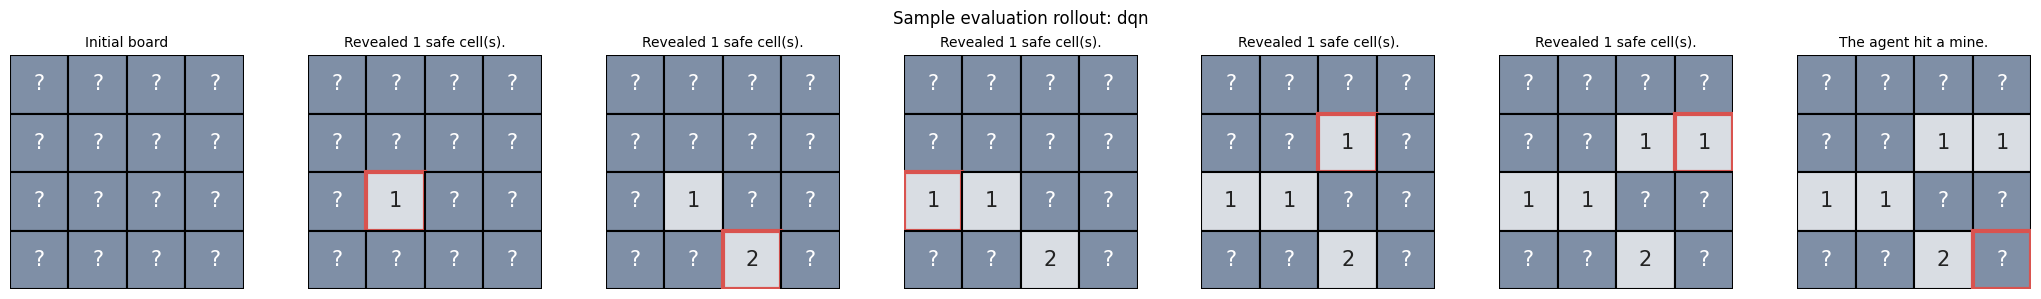

KeyError: 'reinforce'

In [7]:
show_rollout(results, 'dqn', size=env_config['size'])
show_rollout(results, 'reinforce', size=env_config['size'])
show_rollout(results, 'actor_critic', size=env_config['size'])


## Your tasks

1. Tune the neural network architectures manually.
2. Tune the epsilon schedule for DQN.
3. Tune the learning-rate schedules for DQN, REINFORCE, and actor-critic.
4. Compare the algorithms on the default `4x4`, `3`-mine setup.
5. If one configuration works reasonably well, try a harder board such as `5x5`.

Questions worth asking:
- Which algorithm is easiest to stabilize on this environment?
- Does a larger network help, or just make training noisier?
- How sensitive is DQN to the epsilon schedule?
- How sensitive are policy-gradient methods to the learning-rate schedule?
- Does one method benefit more from reward shaping than the others?
- At what point does the problem become too large for these simple baseline networks?
